In [1]:
# Parameters
eval_start = "2024-08-01"
eval_end = "2024-09-15"
dataset_choice = "imerg"
eval_vars = "total_precipitation_6hr"
apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/"
params_path_old = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz'

params_path_new = '/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2024-06-01_2024-07-30_FORECAST28.npz'
norms_dir = '/Datastorage/saptarishi.dhanuka_asp25/gc_norms/'
plots_dir = 'plots/evals'
latmin, latmax, lonmin, lonmax = 6, 38, 35, 65
plot_timesteps = 7
output_pred_old_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'
output_pred_finetuned_dir = '/Datastorage/saptarishi.dhanuka_asp25/preds_dir/'


In [2]:
# Parameters
eval_start = "2024-08-01"
eval_end = "2024-09-15"
dataset_choice = "imerg"
eval_vars = "total_precipitation_6hr"
apath = "/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/"
params_path_old = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/origs/graphcast_1_13.npz"
params_path_new = "/Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig_2024-06-01_2024-07-30_FORECAST28.npz"
norms_dir = "/Datastorage/saptarishi.dhanuka_asp25/gc_norms/"
plots_dir = "plots/evals"
latmin = 6
latmax = 38
lonmin = 35
lonmax = 65
plot_timesteps = 7
output_pred_old_dir = "/Datastorage/saptarishi.dhanuka_asp25/preds_dir/"
output_pred_finetuned_dir = "/Datastorage/saptarishi.dhanuka_asp25/preds_dir/"


In [3]:
"""
Complete evaluation of forecast against different datasets
"""
import os
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
import logging
import argparse
import dataclasses
import xarray as xr
import numpy as np
import pandas as pd
from datetime import datetime
from tqdm import tqdm
import time
import zarr
import matplotlib.pyplot as plt
# import pynvml

import jax
import optax

from graphcast import checkpoint, data_utils, rollout, graphcast, normalization
import save_params_utils
import setup_jax_functions
from plotting import scale, select, plot_data, save_animation, save_static_plot
from metrics import compute_rmse, compute_mae, compute_bias, compute_acc
from utils import regrid_hres_fine_to_coarse, generate_sample_era5_dataset, grads_fn
print(sys.path)
sys.path.append('/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/gc_dist')
import trainer.dataloader
from dist_utils import construct_era5_imerg

# current_date = datetime.now().strftime("%Y-%m-%d_%H-%M")

# # jax.config.update('jax_disable_jit', True)
# # for memory efficiency
# os.environ['XLA_PYTHON_CLIENT_PREALLOCATE']='false'
# os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '2.0' 
# os.environ["XLA_PYTHON_CLIENT_ALLOCATOR"]="platform"

# mean_by_level = None
# stddev_by_level = None
# diffs_stddev_by_level = None
# model_config = None
# task_config = None
# params = None
# state = None

['/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast/local_files', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python311.zip', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/lib-dynload', '', '/home/saptarishi.dhanuka_asp25/.local/lib/python3.11/site-packages', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/eccc_rpnpy-2.2.0rc3-py3.11.egg', '/home/saptarishi.dhanuka_asp25/.conda/envs/graphcast_fine/lib/python3.11/site-packages/fstd2nc-0.20240401.0-py3.11.egg', '/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast', '/home/saptarishi.dhanuka_asp25/weather/graphcast_dir/graphcast']


In [4]:
select_time_evals = []

if dataset_choice == "imerg":
    apath = '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/'
    dbase,_ = trainer.dataloader.open_databases(apath,None) # Note no need for a separate verification dbase
    dbase = construct_era5_imerg(dbase)
    eval_time_ds = dbase.sel(time=slice(eval_start, eval_end))
    del dbase


input_vars = ['10m_u_component_of_wind',
            'geopotential_at_surface',
            '10m_v_component_of_wind',
            'specific_humidity',
            'land_sea_mask',
            'vertical_velocity',
            'geopotential',
            'v_component_of_wind',
            'temperature',
            'total_precipitation_6hr',
            'mean_sea_level_pressure',
            '2m_temperature',
            'u_component_of_wind']

eval_time_ds = eval_time_ds.expand_dims(batch=1)
eval_time_ds = eval_time_ds.rename({'latitude': 'lat', 'longitude': 'lon'})

datetime_array = eval_time_ds['time'].values
# Calculate the time coordinate in 6-hour increments (in nanoseconds)
time_array = np.arange(0, len(datetime_array) * 21600000000000, 21600000000000, dtype='timedelta64[ns]')

# Add the new 'time' coordinate to the dataset
final_eval_ds = eval_time_ds.assign_coords(datetime=('time', time_array))

temp_time = final_eval_ds.coords["time"].copy()
temp_datetime = final_eval_ds.coords["datetime"].copy()

# Reassign the coordinates, swapping their values
final_eval_ds = final_eval_ds.assign_coords(
    time=temp_datetime,
    datetime=temp_time
)

# final_eval_ds['geopotential_at_surface'] = final_eval_ds['geopotential_at_surface'].isel(batch=0, time=0)
# final_eval_ds['land_sea_mask'] = final_eval_ds['land_sea_mask'].isel(batch=0, time=0)

old_datetime = final_eval_ds["datetime"].values  # shape (1489,)

# For our purposes, we want the coordinate to have shape (batch, time). Since the batch
# dimension is of length 1, we can simply add a new axis.
new_datetime = old_datetime[np.newaxis, :]  # shape becomes (1, 1489)

# Now, reassign the "datetime" coordinate to have dims ("batch", "time").
final_eval_ds = final_eval_ds.assign_coords(datetime=(("batch", "time"), new_datetime))

print(f"Coordinates after reassigning: {final_eval_ds.coords}\n")
final_eval_ds

Found ['/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/02', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/03', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/04', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/05', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/06', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/07', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/08', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/09', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/10', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/11', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2023/12', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/01', '/Datastorage/saptarishi.dhanuka_asp25/era5_data/era5_cache/2024/02', '/Datastorage

Concatenating monthly databases


Looping through era5 days for conversion:   0%|                                                                                | 0/871 [00:00<?, ?it/s]

Looping through era5 days for conversion:   0%|                                                                        | 1/871 [00:00<01:31,  9.48it/s]

Looping through era5 days for conversion:   1%|▌                                                                       | 7/871 [00:00<00:23, 36.54it/s]

...

Looping through era5 days for conversion:  72%|██████████████████████████████████████████████████▏                   | 625/871 [00:11<00:04, 55.50it/s]

Exceeded IMERG timespan, stopped replacing with IMERG


✅ All ERA5 6-hourly values match the converted IMERG values (where IMERG is valid).


Coordinates after reassigning: Coordinates:
    expver    (time) <U4 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat       (lat) float64 1kB -90.0 -89.0 -88.0 -87.0 ... 87.0 88.0 89.0 90.0
  * level     (level) uint64 296B 1 2 3 5 7 10 20 ... 875 900 925 950 975 1000
  * lon       (lon) float64 3kB 0.0 1.0 2.0 3.0 4.0 ... 356.0 357.0 358.0 359.0
    number    int64 8B 0
    datetime  (batch, time) datetime64[ns] 1kB 2024-08-01 ... 2024-09-15T18:0...
  * time      (time) timedelta64[ns] 1kB 0 days 00:00:00 ... 45 days 18:00:00



<xarray.Dataset> Size: 11GB
Dimensions:                  (batch: 1, time: 184, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 1kB 2024-08-01 ... ...
  * time                     (time) timedelta64[ns] 1kB 0 days 00:00:00 ... 4...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    2m_temperature           (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    geopotential             (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    land_sea_mask            (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    temperature              (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [5]:
select_time_eval = final_eval_ds
select_time_eval

<xarray.Dataset> Size: 11GB
Dimensions:                  (batch: 1, time: 184, lat: 181, lon: 360, level: 37)
Coordinates:
    expver                   (time) <U4 3kB dask.array<chunksize=(1,), meta=np.ndarray>
  * lat                      (lat) float64 1kB -90.0 -89.0 -88.0 ... 89.0 90.0
  * level                    (level) uint64 296B 1 2 3 5 7 ... 925 950 975 1000
  * lon                      (lon) float64 3kB 0.0 1.0 2.0 ... 357.0 358.0 359.0
    number                   int64 8B 0
    datetime                 (batch, time) datetime64[ns] 1kB 2024-08-01 ... ...
  * time                     (time) timedelta64[ns] 1kB 0 days 00:00:00 ... 4...
Dimensions without coordinates: batch
Data variables: (12/13)
    10m_u_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    10m_v_component_of_wind  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    2m_temperature           (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
    geopotential             (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    geopotential_at_surface  (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    land_sea_mask            (batch, lat, lon) float32 261kB dask.array<chunksize=(1, 181, 360), meta=np.ndarray>
    ...                       ...
    specific_humidity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    temperature              (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    u_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    v_component_of_wind      (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    vertical_velocity        (batch, time, level, lat, lon) float32 2GB dask.array<chunksize=(1, 1, 37, 181, 360), meta=np.ndarray>
    total_precipitation_6hr  (batch, time, lat, lon) float32 48MB dask.array<chunksize=(1, 1, 181, 360), meta=np.ndarray>
Attributes:
    Conventions:             CF-1.7
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    history:                 2025-06-29T18:17 GRIB to CDM+CF via cfgrib-0.9.1...
    institution:             European Centre for Medium-Range Weather Forecasts

In [6]:
data_len = len(select_time_eval.time.values)
data_len

184

In [7]:
select_time_evals = []
for time_slice in range(0, data_len, 28):
    select_time_evals.append(select_time_eval.isel(time=slice(time_slice, time_slice+28)))

In [8]:
for ds in select_time_evals:
    print(ds.datetime.values[0][0])

2024-08-01T00:00:00.000000000
2024-08-08T00:00:00.000000000
2024-08-15T00:00:00.000000000
2024-08-22T00:00:00.000000000
2024-08-29T00:00:00.000000000
2024-09-05T00:00:00.000000000
2024-09-12T00:00:00.000000000


In [9]:
sims = len(select_time_evals)
sims

7

In [10]:
eval_trial_batches = []
from dask.diagnostics import ProgressBar
for i in tqdm(range(sims-1)):
    with ProgressBar():
        eval_trial_batches.append(select_time_evals[i].load())

  0%|                                                                                                                            | 0/6 [00:00<?, ?it/s]

[                                        ] | 0% Completed | 235.19 us

[                                        ] | 0% Completed | 412.43 ms

[                                        ] | 0% Completed | 547.61 ms

[#####                                   ] | 14% Completed | 666.52 ms

...

[#############################           ] | 72% Completed | 1.62 s

[#################################       ] | 82% Completed | 1.72 s

[########################################] | 100% Completed | 1.82 s

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:13<00:00,  2.27s/it]

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6/6 [00:13<00:00,  2.30s/it]

In [11]:
# print(f"Eval batch first time: {eval_trial_batch.time.values[0]}")


with open(params_path_old, 'rb') as f:
    ckpt = checkpoint.load(f, graphcast.CheckPoint)

params = ckpt.params

with open(f'{norms_dir}diffs_stddev_by_level.nc', 'rb') as f:
    diffs_stddev_by_level = xr.load_dataset(f).compute()
with open(f'{norms_dir}stddev_by_level.nc', 'rb') as f:
    stddev_by_level = xr.load_dataset(f).compute()
with open(f'{norms_dir}mean_by_level.nc', 'rb') as f:
    mean_by_level = xr.load_dataset(f).compute()

state = {}
model_config = ckpt.model_config
task_config = ckpt.task_config
setup_jax_functions.configs['model_config'] = model_config
setup_jax_functions.configs['task_config'] = task_config
setup_jax_functions.configs['state'] = state
setup_jax_functions.configs['params'] = params
setup_jax_functions.configs['stddev_by_level'] = stddev_by_level
setup_jax_functions.configs['diffs_stddev_by_level'] = diffs_stddev_by_level
setup_jax_functions.configs['mean_by_level'] = mean_by_level

setup_jax_functions.update_configs({
'params': ckpt.params,
'state': {},
'model_config': ckpt.model_config,
'task_config': ckpt.task_config,
'mean_by_level': mean_by_level,
'stddev_by_level': stddev_by_level,
'diffs_stddev_by_level': diffs_stddev_by_level
})

init_jitted = jax.jit(setup_jax_functions.with_configs(setup_jax_functions.run_forward.init))
loss_fn_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.loss_fn.apply))))
grads_fn_jitted = setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(setup_jax_functions.grads_fn)))
run_forward_jitted = setup_jax_functions.drop_state(setup_jax_functions.with_params(jax.jit(setup_jax_functions.with_configs(
setup_jax_functions.run_forward.apply))))

def run_model(params, state, inputs, targets_template, forcings):
    predictions = run_forward_jitted(
    rng=jax.random.PRNGKey(0),
    inputs=inputs,
    targets_template=targets_template,
    forcings=forcings,
    params=params,
    state=state
)
    return predictions

In [12]:
# need to make sure that the .npz and the .opt are both new and .opt isnt the old one
import os
import numpy as np
import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from graphcast import checkpoint, graphcast

f = open(params_path_new, "rb")
new_ckpt = checkpoint.load(f, graphcast.CheckPoint)
new_params = new_ckpt.params
f.close()
params_keys_list = list(new_params.keys())
any_not_nan = any(not np.isnan(x) for x in list(new_params[f'{params_keys_list[0]}'].values())[1])
if not any_not_nan:
    print("All values are NaN")
else:
    print("Valid values are there!")
!ls -lth /Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz

Valid values are there!
-rw-r--r-- 1 saptarishi.dhanuka_asp25 saptarishi.dhanuka_asp25 138M Jul  5 06:56 /Datastorage/saptarishi.dhanuka_asp25/gc_weights/graphcast_1_13_orig.npz


Eval batch time dimensions: 28
Eval Inputs:    {'batch': 1, 'time': 2, 'lat': 181, 'lon': 360, 'level': 13}
Eval Targets:   {'batch': 1, 'time': 16, 'lat': 181, 'lon': 360, 'level': 13}
Eval Forcings:  {'batch': 1, 'time': 16, 'lat': 181, 'lon': 360}
Running old params


Predictions Old:  {'time': 16, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}
Running new params


Predictions Finetuned:  {'time': 16, 'batch': 1, 'lat': 181, 'lon': 360, 'level': 13}


  0%|                                                                                                                           | 0/16 [00:00<?, ?it/s]

  6%|███████▏                                                                                                           | 1/16 [00:00<00:05,  2.86it/s]

...

 88%|███████████████████████████████████████████████████████████████████████████████████████████████████▊              | 14/16 [00:02<00:00,  5.53it/s]

 94%|██████████████████████████████████████████████████████████████████████████████████████████████████████████▉       | 15/16 [00:02<00:00,  5.54it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  5.53it/s]

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 16/16 [00:03<00:00,  5.26it/s]

[array(1.35060745e-05, dtype=float32), array(2.1067448e-05, dtype=float32), array(1.9904579e-05, dtype=float32), array(1.6616432e-05, dtype=float32), array(1.3899595e-05, dtype=float32), array(2.5045785e-05, dtype=float32), array(2.530338e-05, dtype=float32), array(2.0163008e-05, dtype=float32), array(1.8204102e-05, dtype=float32), array(1.4523295e-05, dtype=float32), array(1.509921e-05, dtype=float32), array(1.14722325e-05, dtype=float32), array(9.840215e-06, dtype=float32), array(1.0453731e-05, dtype=float32), array(1.0861781e-05, dtype=float32), array(9.45036e-06, dtype=float32)]
[array(1.0866977e-05, dtype=float32), array(1.883847e-05, dtype=float32), array(1.744544e-05, dtype=float32), array(1.4362122e-05, dtype=float32), array(1.2075657e-05, dtype=float32), array(2.1193751e-05, dtype=float32), array(1.982432e-05, dtype=float32), array(1.7272092e-05, dtype=float32), array(1.6687527e-05, dtype=float32), array(1.3326574e-05, dtype=float32), array(1.4546119e-05, dtype=float32), array

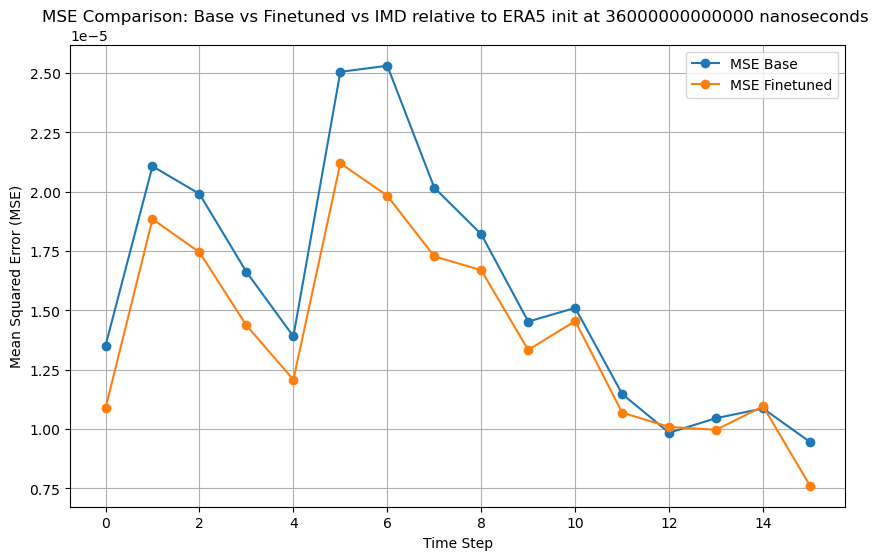

<Figure size 640x480 with 0 Axes>

In [13]:
from plotting import compute_difference_with_targets_sims
from utils import compute_mse, compute_mse_diffs

time_len = len(eval_trial_batches[0].time.values)
eval_sim_data = eval_trial_batches[0].isel(time=slice(0, time_len-1))
eval_inputs, eval_targets, eval_forcings = data_utils.extract_inputs_targets_forcings(
eval_sim_data, target_lead_times=slice("6h", "100h"),
**dataclasses.asdict(task_config))
forecast_len = len(eval_targets.time.values)

assert eval_trial_batches[0].sizes["time"] >= 3

print(f"Eval batch time dimensions: {eval_trial_batches[0].sizes['time']}")

task_config_dict =  dataclasses.asdict(task_config)

print("Eval Inputs:   ", eval_inputs.dims.mapping)
print("Eval Targets:  ", eval_targets.dims.mapping)
print("Eval Forcings: ", eval_forcings.dims.mapping)

targets_template = eval_targets * np.nan

print("Running old params")
predictions_old = run_model(params, state, eval_inputs, targets_template, eval_forcings)

print("Predictions Old: ", predictions_old.dims.mapping)

print("Running new params")

predictions_finetuned = run_model(new_params, state, eval_inputs, targets_template, eval_forcings)
print("Predictions Finetuned: ", predictions_finetuned.dims.mapping)


diff_fine, diff_old = [], []
for time_step in tqdm(range(forecast_len)):
    diff_fine.append(compute_difference_with_targets_sims(predictions_finetuned,eval_targets,time_step, 'total_precipitation_6hr', plots_dir=plots_dir))
    diff_old.append(compute_difference_with_targets_sims(predictions_old,eval_targets,time_step, 'total_precipitation_6hr', plots_dir=plots_dir))


# Compute the MSE for each time step and aggregate
mse_finetuned = []
mse_base = []
mse_imd_era5 = []
for diff_counter in range(len(diff_fine)):
    mse_diff_finetuned = compute_mse_diffs(diff_fine[diff_counter])
    mse_diff_base = compute_mse_diffs(diff_old[diff_counter])
    # mse_diff_imd_era5 = compute_mse_diffs(differences_era5_imd[diff_counter])
    
    mse_finetuned.append(mse_diff_finetuned)
    mse_base.append(mse_diff_base)
    # mse_imd_era5.append(mse_diff_imd_era5)

print(mse_base)
print(mse_finetuned)

# Plot the line chart
plt.figure(figsize=(10, 6))
plt.plot(list(range(forecast_len)), mse_base, label='MSE Base', marker='o')
plt.plot(list(range(forecast_len)), mse_finetuned, label='MSE Finetuned', marker='o')
# plt.plot(list(range(4)), mse_imd_era5, label='MSE IMD', marker='o')
# plt.plot(time_steps, mse_imd_era5, label='MSE IMD ERA5', marker='x')

# Annotate the first and last points for MSE Base

# plt.annotate(f"{mse_base[0]:.4f}", (0, mse_base[0]), textcoords="offset points", xytext=(-10, 10), ha='center')
# plt.annotate(f"{mse_base[-1]:.4f}", (6, mse_base[-1]), textcoords="offset points", xytext=(-10, 10), ha='center')


# Add labels, title, and legend
plt.xlabel('Time Step')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'MSE Comparison: Base vs Finetuned vs IMD relative to ERA5 init at {eval_targets.time.values[0]} ')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()
plt.clf()
# diff_imd.append(plot_diff_imd_era5

In [14]:
# predictions_old.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_old_india_2023_6.nc")
# predictions_finetuned.to_netcdf(f"/Datastorage/saptarishi.dhanuka_asp25/preds_dir/predictions_finetuned_india2023_6.nc")